# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [2]:
%pip install phik
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from sqlalchemy import create_engine

     |████████████████████████████████| 677 kB 2.2 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
db_config = {
    'user': 'praktikum_student',
    'password': 'Sdf4$2;d-d30pp',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'database': 'data-analyst-afisha'
}

connection_string = (
    f"postgresql://{db_config['user']}:{db_config['password']}"
    f"@{db_config['host']}:{db_config['port']}/{db_config['database']}"
)

engine = create_engine(connection_string)

In [4]:
query = """
SELECT
    user_id,
    device_type_canonical,
    order_id,
    date(created_dt_msk) AS order_dt,
    created_ts_msk AS order_ts,
    currency_code,
    revenue,
    tickets_count,
    created_dt_msk::date
        - LAG(created_dt_msk::date) OVER (
            PARTITION BY user_id
            ORDER BY created_dt_msk
        ) AS days_since_prev,
    p.event_id,
    event_name_code AS event_name,
    event_type_main,
    service_name,
    region_name,
    city_name
FROM afisha.purchases AS p
LEFT JOIN afisha.events AS e
    ON e.event_id = p.event_id
LEFT JOIN afisha.city AS c
    ON c.city_id = e.city_id
LEFT JOIN afisha.regions AS r
    ON r.region_id = c.region_id
WHERE device_type_canonical IN ('mobile', 'desktop')
  AND event_type_main <> 'фильм'
ORDER BY user_id;
"""

In [5]:
df = pd.read_sql(query, engine)

Данные подгружены, датафрейм создан

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  object        
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Датафрейм содержит 290611 строк и 15 столбцов. Есть пропуски в данных только в столбце days_since_prev, это нормально так как у пользователя может быть только одна покупка. Необходимости менять типы данных нет.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [7]:
dfkurs=pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [8]:
print(dfkurs)

           data  nominal     curs  cdx
0    2024-01-10      100  19.9391  kzt
1    2024-01-11      100  19.7255  kzt
2    2024-01-12      100  19.5839  kzt
3    2024-01-13      100  19.4501  kzt
4    2024-01-14      100  19.4501  kzt
..          ...      ...      ...  ...
352  2024-12-27      100  19.2705  kzt
353  2024-12-28      100  19.5105  kzt
354  2024-12-29      100  19.4860  kzt
355  2024-12-30      100  19.4860  kzt
356  2024-12-31      100  19.4860  kzt

[357 rows x 4 columns]


In [9]:
dfkurs['data'] = pd.to_datetime(dfkurs['data']).dt.date
df=df.merge(dfkurs,how='left',left_on='order_dt',right_on='data')

In [10]:
df['revenue_rub'] = df['revenue']
df.loc[df['currency_code']=='kzt','revenue_rub']=df['revenue']/df['nominal']*df['curs']

Был добавлен новый столбец с расчетом стоимости в рублях.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [11]:
print(df.duplicated().sum())

0


Явных дубликатов необнаружено.

In [12]:
print(df['device_type_canonical'].unique())
print(df['currency_code'].unique())
print(df['service_name'].unique())

['mobile' 'desktop']
['rub' 'kzt']
['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино билет' 'Цвет и билет' 'Зе Бест!'
 'Тех билет' 'Лимоны' 'Билеты в интернете']


Просмотрев столбцы, где вероятнее всего могли бы быть неявные дубликаты, их не было обнаружено.

In [13]:
df['event_type_main'].value_counts()

концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

In [14]:
df['service_name'].value_counts()

Билеты без проблем        63519
Лови билет!               41124
Билеты в руки             40343
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17774
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                   67
Цвет и б

In [15]:
df['region_name'].value_counts()

Каменевский регион          91058
Североярская область        44049
Широковская область         16457
Медовская область           13901
Озернинский край            10476
                            ...  
Лесноярский край               19
Крутоводский регион            18
Верхозёрский край              11
Сосноводолинская область       10
Теплоозёрский округ             7
Name: region_name, Length: 81, dtype: int64

In [16]:
df['city_name'].value_counts()

Глиногорск      89446
Озёрск          43910
Радужсвет       13711
Радужнополье     8741
Верховино        6579
                ...  
Озёроярск           1
Светочистка         1
Полянск             1
Мироград            1
Горнолесье          1
Name: city_name, Length: 352, dtype: int64

Опираясь на это и на ранее исследования, данные не нуждаются в нормализации, все навзания корректны. В данных нет названий, которые обозначают пропуски в данных или отсутствие информации.

In [17]:
df['revenue_rub'].describe()

count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

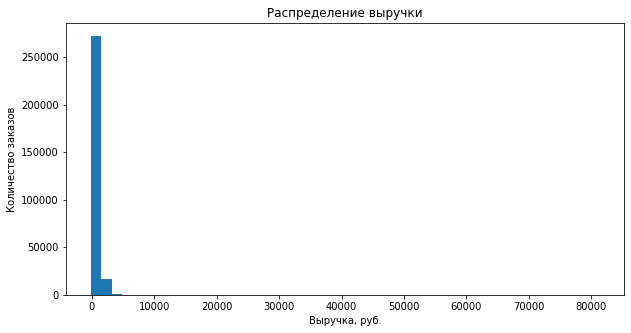

In [18]:
plt.figure(figsize=(10, 5))
plt.hist(df['revenue_rub'], bins=50)
plt.title('Распределение выручки')
plt.xlabel('Выручка, руб.')
plt.ylabel('Количество заказов')
plt.show()

на графике видно что большее количество значений не превышает примерно  3000 рублей, значит максимальное значение в 81174 рублей очень большой выброс, который нужно убрать.


In [19]:
df = df[df['revenue_rub'] <= df['revenue_rub'].quantile(0.99)]

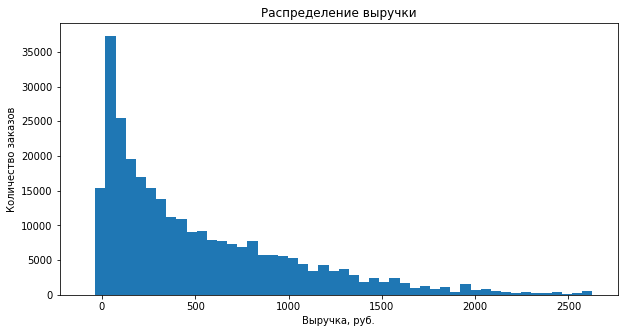

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(df['revenue_rub'], bins=50)
plt.title('Распределение выручки')
plt.xlabel('Выручка, руб.')
plt.ylabel('Количество заказов')
plt.show()

Так намного нагляднее, здесь видно что в основном все данные сосредаточены в диапозоне от 0 до 500 рублей выручки, а дальше количество данных стремительно падает, в зависимости от роста выручки. Можно сказать что среднее значение значительно больше медианы, данные расположены не равномерно, с сильным смещением в большую сторону. Так же минимальное значение в данных отрицательно, возможно это ошибка в данных, либо возврат с какой то компенсацией.

In [21]:
df['tickets_count'].describe()

count    287786.000000
mean          2.740495
std           1.163073
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

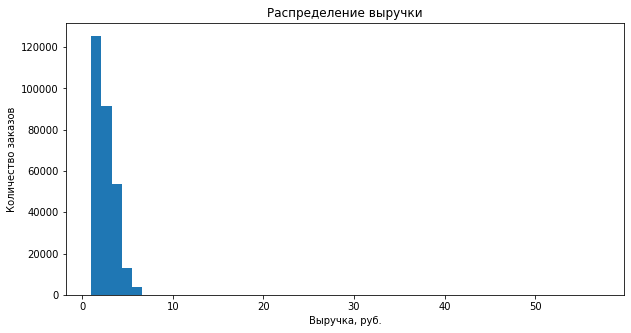

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(df['tickets_count'], bins=50)
plt.title('Распределение выручки')
plt.xlabel('Выручка, руб.')
plt.ylabel('Количество заказов')
plt.show()

В столбце с количеством билетов также присутствует выброс в 57, корректно будет его убрать

In [23]:
df=df.loc[df['tickets_count']<=df['tickets_count'].quantile(0.99)]

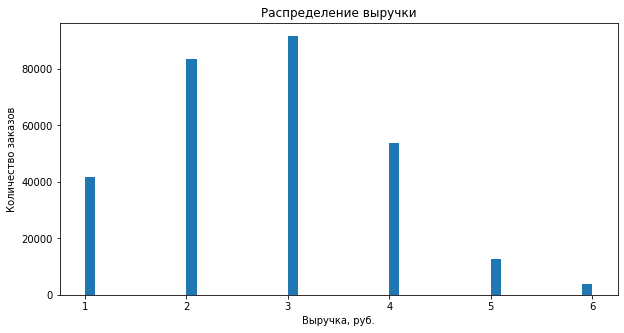

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(df['tickets_count'], bins=50)
plt.title('Распределение выручки')
plt.xlabel('Выручка, руб.')
plt.ylabel('Количество заказов')
plt.show()

В столбце с количество билетов ситуация иначе, данные показаны развномерно с небольшим смещением в большую сторону, это подтверждает небольшая разница медианного и среднего значения  

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [25]:
df1=df.groupby('user_id').agg({'order_dt':['min','max','count'],
                           'revenue_rub':'mean','tickets_count':'mean','days_since_prev':'mean'})

In [26]:
df1.columns = [
    'first_order_dt',
    'last_order_dt',
    'orders_count',
    'avg_revenue_rub',
    'avg_tickets_count',
    'avg_days_since_prev'
]

In [27]:
firstord=df.sort_values('order_ts').drop_duplicates(subset='user_id')

In [28]:
firstord=firstord[['user_id',
'device_type_canonical',
'region_name',
'service_name',
'event_type_main']]

In [29]:
firstord=firstord.rename(columns={'device_type_canonical':'first_device_type',
                                  'region_name':'first_region_name','service_name':'first_service_name',
                                 'event_type_main':'first_event_type_main'})

In [30]:
df1=df1.merge(firstord,how='left',on='user_id')

Был сделан профиль для каждого пользователя, найдены все необходимые характеристики 

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [31]:
# Общее количество пользователей
print('Количество пользователей:', df1.shape[0])

Количество пользователей: 21847


In [32]:
print('Средняя выручка с заказа:', df1['avg_revenue_rub'].mean())

Средняя выручка с заказа: 544.1610668323726


In [33]:
print('Доля пользователей с 2 и более заказами:',
      (df1['orders_count'] >= 2).mean())

Доля пользователей с 2 и более заказами: 0.6170183549228727


In [34]:
print('Доля пользователей с 5 и более заказами:',
      (df1['orders_count'] >= 5).mean())

Доля пользователей с 5 и более заказами: 0.29006270883874213


In [35]:
print(df1['orders_count'].describe())

count    21847.000000
mean        13.164553
std        121.581813
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10168.000000
Name: orders_count, dtype: float64


Среднее количество заказов равно 13,16, но медиана составляет всего 2. Максимальное значение — 10168 заказов, что говорит о наличии сильных выбросов. Для дальнейшего анализа данные стоит отфильтровать.Попробую отфильтровать их по 99 процентилю 

In [36]:
p99 = df1['orders_count'].quantile(0.99)

df1 = df1[df1['orders_count'] <= p99]
print(df1['orders_count'].describe())

count    21628.000000
mean         6.479980
std         14.218483
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        151.000000
Name: orders_count, dtype: float64


Уже лучше, но выбросы все еще присутствуют,попробую отфильтровать данные по 95 процентилю 

In [37]:
p95 = df1['orders_count'].quantile(0.95)

df1 = df1[df1['orders_count'] <= p95]
print(df1['orders_count'].describe())

count    20565.000000
mean         3.822271
std          4.551866
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         26.000000
Name: orders_count, dtype: float64


Так лучше, с такими данными намного надежднее работать.

In [38]:
print(df1['avg_tickets_count'].describe())

count    20565.000000
mean         2.739765
std          0.927625
min          1.000000
25%          2.000000
50%          2.750000
75%          3.166667
max          6.000000
Name: avg_tickets_count, dtype: float64


Среднее количество билетов в заказе составляет 2,74. Максимальное значение — 6, сильных выбросов не наблюдается.

In [39]:
print(df1['avg_days_since_prev'].describe())

count    12234.000000
mean        17.215197
std         22.974612
min          0.000000
25%          1.000000
50%          9.727273
75%         22.500000
max        148.000000
Name: avg_days_since_prev, dtype: float64


Среднее время между заказами составляет 15,82 дня, медиана — 8 дней. Максимальное значение — 148 дней. Встречаются большие интервалы между покупками, но они могут быть реальным поведением пользователей

In [40]:
#Итоговое количество польхователей с учетом фильтрации
print('Количество пользователей:', df1.shape[0])

Количество пользователей: 20565


---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [41]:
# Распределение по типу первого мероприятия
print(df1['first_event_type_main'].value_counts())
print(df1['first_event_type_main'].value_counts(normalize=True))

концерты    9096
другое      5125
театр       4025
стендап     1063
спорт        761
выставки     401
ёлки          94
Name: first_event_type_main, dtype: int64
концерты    0.442305
другое      0.249210
театр       0.195721
стендап     0.051690
спорт       0.037005
выставки    0.019499
ёлки        0.004571
Name: first_event_type_main, dtype: float64


Большинство пользователей впервые покупают билеты на концерты (около 44%). Также значительную долю составляют категории «другое» (25%) и театр (20%). Остальные типы мероприятий встречаются значительно реже. Это говорит о том, что основными точками входа являются концерты и театральные мероприятия.

In [42]:
# Распределение по устройству первого заказа
print(df1['first_device_type'].value_counts())
print(df1['first_device_type'].value_counts(normalize=True))

mobile     17069
desktop     3496
Name: first_device_type, dtype: int64
mobile     0.830002
desktop    0.169998
Name: first_device_type, dtype: float64


Большинство пользователей (83%) совершают первый заказ с мобильного устройства, тогда как с компьютера — около 17%. Следовательно, мобильные устройства являются основным каналом первого взаимодействия с платформой.

In [43]:
# Распределение по региону первого заказа
print(df1['first_region_name'].value_counts())
print(df1['first_region_name'].value_counts(normalize=True))

Каменевский регион          6713
Североярская область        3560
Широковская область         1176
Озернинский край             657
Малиновоярский округ         510
                            ... 
Тихогорская область            2
Сосноводолинская область       1
Светолесский край              1
Верхозёрский край              1
Яснопольский округ             1
Name: first_region_name, Length: 81, dtype: int64
Каменевский регион          0.326428
Североярская область        0.173110
Широковская область         0.057185
Озернинский край            0.031947
Малиновоярский округ        0.024799
                              ...   
Тихогорская область         0.000097
Сосноводолинская область    0.000049
Светолесский край           0.000049
Верхозёрский край           0.000049
Яснопольский округ          0.000049
Name: first_region_name, Length: 81, dtype: float64


Пользователи распределены по регионам неравномерно. Наибольшее число первых заказов приходится на Каменевский регион (около 33%) и Североярскую область (17%). Остальные регионы имеют заметно меньшую долю пользователей.

In [44]:
# Распределение по билетному оператору первого заказа
print(df1['first_service_name'].value_counts())
print(df1['first_service_name'].value_counts(normalize=True))

Билеты без проблем        4909
Мой билет                 2831
Лови билет!               2684
Билеты в руки             2402
Облачко                   2090
Весь в билетах            1222
Лучшие билеты             1123
Прачечная                  544
Край билетов               433
Дом культуры               337
Яблоко                     307
Тебе билет!                296
Городской дом культуры     206
За билетом!                196
Мир касс                   195
Быстробилет                159
Show_ticket                152
Выступления.ру              92
Восьмёрка                   82
Быстрый кассир              53
Crazy ticket!               42
Росбилет                    40
Радио ticket                35
Телебилет                   27
Реестр                      27
Цвет и билет                21
Шоу начинается!             18
КарандашРУ                  14
Кино билет                   9
Вперёд!                      7
Билет по телефону            6
Тех билет                    3
Лимоны  

Первые заказы совершаются через большое количество билетных операторов, однако лидирует оператор «Билеты без проблем». Также заметную долю пользователей привлекают «Мой билет», «Лови билет!», «Билеты в руки» и «Облачко». Это говорит о том, что основная часть пользователей приходит через несколько крупнейших операторов, несмотря на большое количество представленных сервисов.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [45]:
#Создаю индикатор который указывает было два или больше заказа или нет 
df1['is_two'] = 0
df1.loc[df1['orders_count'] >= 2, 'is_two'] = 1

In [46]:
print(df1.groupby('first_event_type_main')['is_two'].mean())

first_event_type_main
выставки    0.628429
другое      0.572683
концерты    0.598835
спорт       0.538765
стендап     0.591722
театр       0.614410
ёлки        0.553191
Name: is_two, dtype: float64


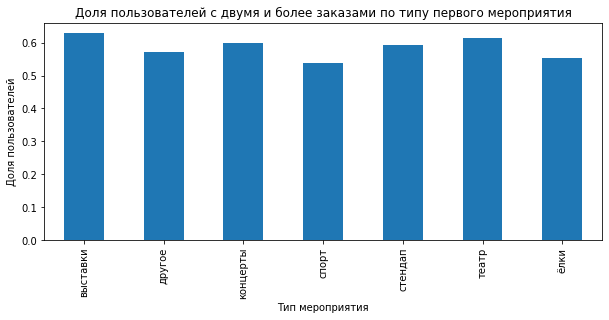

In [47]:
plt.figure(figsize=(10,4))
df1.groupby('first_event_type_main')['is_two'].mean().plot(kind='bar',
                                                           title='Доля пользователей с двумя и более заказами по типу первого мероприятия',
                                                           ylabel='Доля пользователей',
                                                           xlabel='Тип мероприятия')
plt.show()

Доля пользователей, совершивших повторный заказ, различается незначительно. Чаще всего возвращаются пользователи, впервые купившие билеты на выставки (62,8%) и театр (61,4%). Реже всего возвращаются пользователи, начавшие со спортивных мероприятий (53,9%). В целом тип первого мероприятия оказывает небольшое влияние на вероятность повторной покупки.

In [48]:
print(df1.groupby('first_device_type')['is_two'].mean())

first_device_type
desktop    0.616133
mobile     0.588435
Name: is_two, dtype: float64


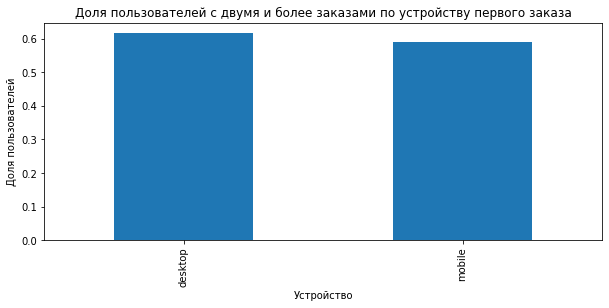

In [49]:
plt.figure(figsize=(10,4))
df1.groupby('first_device_type')['is_two'].mean().plot(kind='bar',
                                                       title='Доля пользователей с двумя и более заказами по устройству первого заказа',
                                                       ylabel='Доля пользователей',
                                                       xlabel='Устройство')
plt.show()

Пользователи, оформившие первый заказ с desktop, возвращаются немного чаще (61,6%), чем пользователи mobile (58,8%). Однако разница невелика, поэтому устройство нельзя считать сильным фактором возврата.

In [50]:
top10 = df1['first_region_name'].value_counts().head(10)

print(df1.groupby('first_region_name')['is_two'].mean().loc[top10.index])

Каменевский регион      0.603158
Североярская область    0.617135
Широковская область     0.630952
Озернинский край        0.540335
Малиновоярский округ    0.547059
Травяная область        0.595699
Шанырский регион        0.639560
Светополянский округ    0.635731
Речиновская область     0.613909
Яблоневская область     0.579345
Name: is_two, dtype: float64


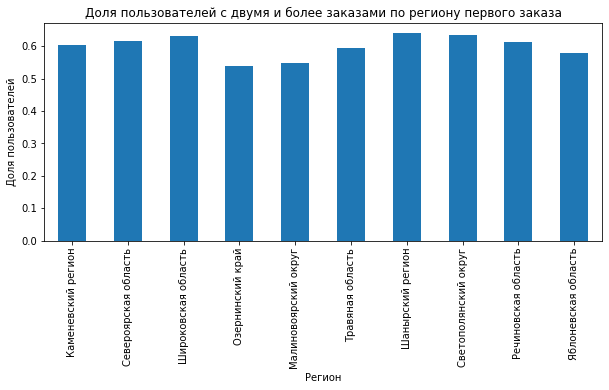

In [51]:
plt.figure(figsize=(10,4))
df1.groupby('first_region_name')['is_two'].mean().loc[top10.index].plot(kind='bar',
    title='Доля пользователей с двумя и более заказами по региону первого заказа',
    ylabel='Доля пользователей',
    xlabel='Регион')
plt.show()

Среди 10 самых многочисленных регионов доля пользователей, совершивших два и более заказа, находится примерно в диапазоне от 54% до 64%. Наибольшая доля повторных заказов наблюдается в Шанырском регионе (63,96%), Светополянском округе (63,57%) и Широковской области (63,10%). Самая низкая доля — в Озернинском крае (54,03%) и Малиновоярском округе (54,71%). Различия между регионами есть, но они не слишком большие, поэтому нельзя выделить один явно лучший регион как точку входа.

In [52]:
top10 = df1['first_service_name'].value_counts().head(10)

print(df1.groupby('first_service_name')['is_two'].mean().loc[top10.index])

Билеты без проблем    0.582400
Мой билет             0.588838
Лови билет!           0.590909
Билеты в руки         0.602831
Облачко               0.596651
Весь в билетах        0.609656
Лучшие билеты         0.591273
Прачечная             0.599265
Край билетов          0.635104
Дом культуры          0.626113
Name: is_two, dtype: float64


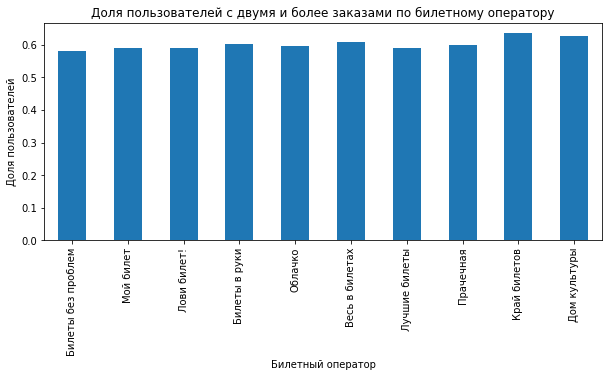

In [53]:
plt.figure(figsize=(10,4))
df1.groupby('first_service_name')['is_two'].mean().loc[top10.index].plot(kind='bar',
    title='Доля пользователей с двумя и более заказами по билетному оператору',
    ylabel='Доля пользователей',
    xlabel='Билетный оператор')
plt.show()

Среди 10 крупнейших билетных операторов доля пользователей с двумя и более заказами составляет примерно от 58% до 64%. Наибольшая доля повторных заказов наблюдается у операторов «Край билетов» (63,51%) и «Дом культуры» (62,61%). Самая низкая доля — у «Билеты без проблем» (58,24%). В целом различия между крупнейшими операторами невелики, поэтому выраженных успешных точек входа среди них не наблюдается.

Чаще возвращаются пользователи, у которых первое мероприятие — выставки и театр, первое устройство — desktop, а среди крупнейших регионов и билетных операторов небольшое преимущество имеют Шанырский регион, Светополянский округ, «Край билетов» и «Дом культуры».Явно выраженных успешных точек входа не наблюдается. Доли повторных заказов между большинством крупных сегментов отличаются незначительно, поэтому нельзя сделать вывод, что какой-либо сегмент существенно превосходит остальные по вероятности возвращения пользователей.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Гипотеза 1

Не подтвердилась. Пользователи, оформившие первый заказ на спортивные мероприятия, возвращаются реже, чем пользователи, купившие билеты на концерты. Доля повторных заказов у спортивных мероприятий составляет около 53,9%, тогда как у концертов — около 59,9%.

Гипотеза 2

Не подтвердилась. Среди самых крупных регионов нет зависимости, что чем больше пользователей в регионе, тем выше доля повторных заказов. Например, Каменевский регион является самым многочисленным, но не имеет самой высокой доли повторных заказов. Следовательно, количество пользователей в регионе не связано напрямую с вероятностью их возвращения.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [54]:
zak1=df1.loc[df1['is_two']==0]
bol2=df1.loc[df1['is_two']==1]

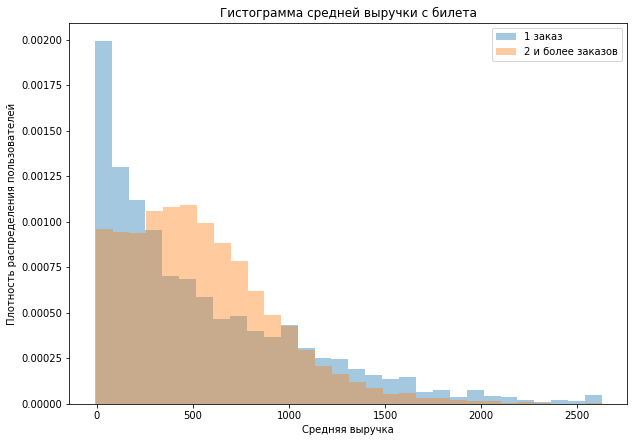

In [55]:
plt.figure(figsize=(10,7))
zak1['avg_revenue_rub'].plot(kind='hist',density=True,
                             bins=30,alpha=0.4)
bol2['avg_revenue_rub'].plot(kind='hist',density=True,
                             bins=30,alpha=0.4)

plt.title('Гистограмма средней выручки с билета')
plt.xlabel('Средняя выручка')
plt.ylabel('Плотность распределения пользователей')
plt.legend(['1 заказ', '2 и более заказов'])

Пользователи, совершившие один заказ, в основном сосредоточены в диапазоне 0–300 руб.
Пользователи, совершившие 2 и более заказа, чаще встречаются в диапазоне 300–700 руб.
Да. Распределение пользователей с повторными заказами смещено в сторону более высокой средней выручки. Это говорит о том, что пользователи, которые тратят больше в среднем на билет, чаще возвращаются на платформу. При этом у обеих групп наблюдается длинный правый хвост — встречаются пользователи с высокой средней выручкой, но их значительно меньше.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [56]:
dff1=df1.loc[(df1['orders_count']<=4) &(df1['orders_count']>=2)]
dff2=df1.loc[df1['orders_count']>=5]

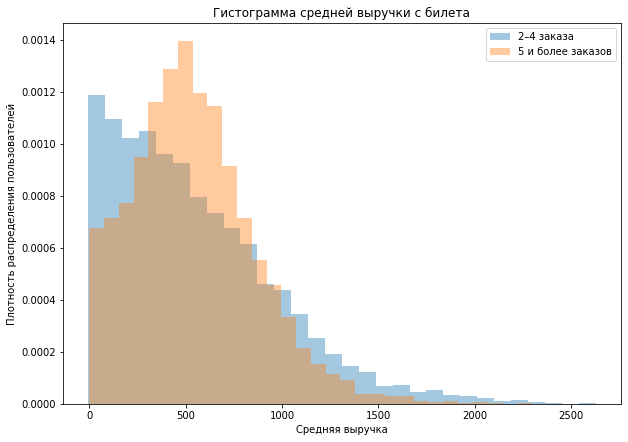

In [57]:
plt.figure(figsize=(10,7))

dff1['avg_revenue_rub'].plot(
    kind='hist',
    density=True,
    bins=30,
    alpha=0.4
)

dff2['avg_revenue_rub'].plot(
    kind='hist',
    density=True,
    bins=30,
    alpha=0.4
)

plt.title('Гистограмма средней выручки с билета')
plt.xlabel('Средняя выручка')
plt.ylabel('Плотность распределения пользователей')
plt.legend(['2–4 заказа', '5 и более заказов'])

plt.show()

Да, различия между группами есть. Пользователи, совершившие 5 и более заказов, чаще имеют среднюю выручку в диапазоне 300–700 руб. Распределение пользователей с 2–4 заказами смещено в сторону более низких значений — основная часть находится в диапазоне 0–500 руб. При этом у обеих групп наблюдается длинный правый хвост, то есть встречаются пользователи с высокой средней выручкой, но их доля невелика.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

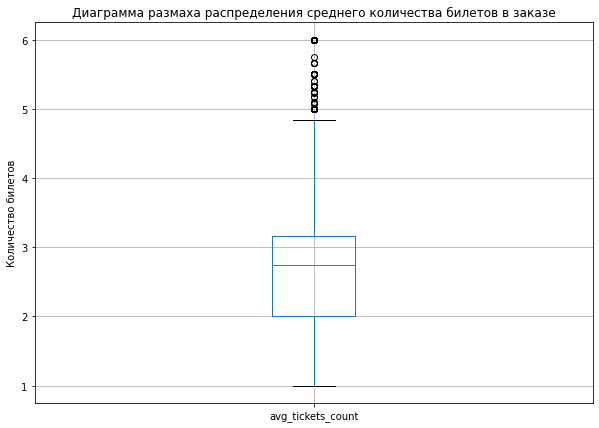

In [58]:
plt.figure(figsize=(10,7))
df1['avg_tickets_count'].plot(kind='box',
                              title='Диаграмма размаха распределения среднего количества билетов в заказе',
                             ylabel='Количество билетов',
                             )
plt.grid()
plt.show()

Медианное среднее количество билетов в заказе составляет около 2,7, при этом основная масса пользователей покупает 2–3 билета. Распределение имеет правостороннюю асимметрию: встречаются многочисленные выбросы со средним количеством 5–6 билетов, однако таких пользователей немного.

In [59]:
# Создаю новый столбец чтобы разделить пользователей на группы
# Создаю интервалы, чтобы пользователи у которых целое среднее число заказов не попали в несколько групп

df1['group'] = ''

df1.loc[(df1['avg_tickets_count'] < 2), 'group'] = '1-2'
df1.loc[(df1['avg_tickets_count'] >= 2) & (df1['avg_tickets_count'] < 3), 'group'] = '2-3'
df1.loc[(df1['avg_tickets_count'] >= 3) & (df1['avg_tickets_count'] < 5), 'group'] = '3-5'
df1.loc[(df1['avg_tickets_count'] >= 5), 'group'] = '5+'

In [60]:
#количество пользователей на каждую группу
print(df1['group'].value_counts())

3-5    8882
2-3    8619
1-2    2416
5+      648
Name: group, dtype: int64


In [61]:
#Доля пользователей совершившие повторные заказы
print(df1.groupby('group')['is_two'].mean())

group
1-2    0.512417
2-3    0.708899
3-5    0.533101
5+     0.177469
Name: is_two, dtype: float64


Пользователи распределены неравномерно. Наибольшая часть пользователей сосредоточена в сегментах 2–3 билета (8619 пользователей) и 3–5 билетов (8882 пользователя). Сегмент 1–2 билета значительно меньше (2416 пользователей), а пользователей со средним количеством 5 и более билетов меньше всего (648 пользователей).
Есть сегменты с аномальной долей повторных покупок. Наиболее высокая доля повторных покупок наблюдается в сегменте 2–3 билета — 70,9%. Наиболее низкая — в сегменте 5 и более билетов — 17,7%. При этом результаты для сегмента 5+ следует интерпретировать осторожно, так как он содержит значительно меньше пользователей по сравнению с остальными сегментами.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [62]:
df1['first_order_dt'] = pd.to_datetime(df1['first_order_dt'])
df1['day_first_order']=df1['first_order_dt'].dt.day_name()

In [63]:
print(df1['day_first_order'].value_counts())

Friday       3139
Saturday     3091
Thursday     3000
Tuesday      2995
Wednesday    2941
Monday       2785
Sunday       2614
Name: day_first_order, dtype: int64


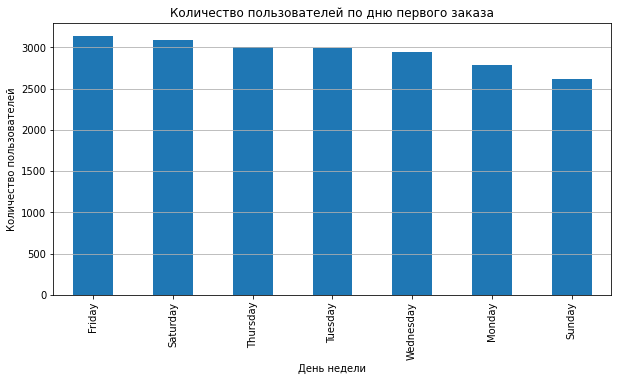

In [64]:
plt.figure(figsize=(10, 5))

df1['day_first_order'].value_counts().plot(
    kind='bar',
    title='Количество пользователей по дню первого заказа',
    xlabel='День недели',
    ylabel='Количество пользователей'
)

plt.grid(axis='y')
plt.show()

In [65]:
print(df1.groupby('day_first_order')['is_two'].mean())

day_first_order
Friday       0.582988
Monday       0.611131
Saturday     0.600453
Sunday       0.575746
Thursday     0.579333
Tuesday      0.595326
Wednesday    0.606596
Name: is_two, dtype: float64


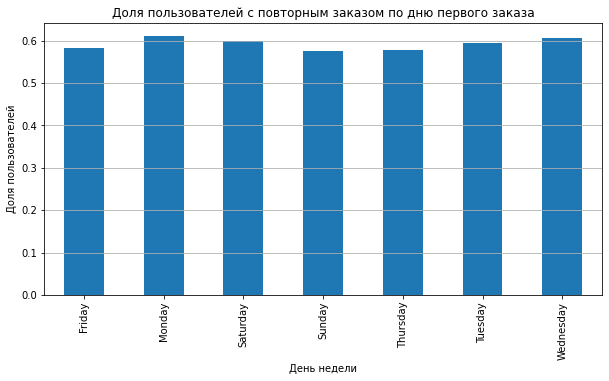

In [66]:
plt.figure(figsize=(10, 5))

df1.groupby('day_first_order')['is_two'].mean().plot(
    kind='bar',
    title='Доля пользователей с повторным заказом по дню первого заказа',
    xlabel='День недели',
    ylabel='Доля пользователей'
)

plt.grid(axis='y')
plt.show()

Существенного влияния не наблюдается. Доля пользователей, совершивших повторный заказ, во все дни недели находится примерно в диапазоне 58–61%. Наибольшая доля повторных покупок приходится на понедельник (61,1%), а наименьшая — на воскресенье (57,6%), однако разница между днями невелика (около 3,5 процентных пункта). Следовательно, день недели первой покупки не оказывает заметного влияния на вероятность возврата пользователя.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [69]:
df1['group1']=''
df1.loc[(df1['avg_tickets_count']>=2)&(df1['avg_tickets_count']<=4),'group1']='2-4'
df1.loc[(df1['avg_tickets_count']>=5),'group1']='5+'

In [70]:
print(df1.groupby('group1')['avg_days_since_prev'].mean())

group1
       15.939291
2-4    17.521405
5+      6.408909
Name: avg_days_since_prev, dtype: float64


Пользователи с 5 и более заказами в среднем совершают повторные заказы чаще: средний интервал составляет 6,41 дня, тогда как у пользователей с 2–4 заказами — 17,52 дня.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [76]:
corr = df1[
    ['orders_count',
     'avg_revenue_rub',
     'avg_tickets_count',
     'avg_days_since_prev',
     'first_device_type',
     'first_region_name',
     'first_service_name',
     'first_event_type_main']
].phik_matrix(
    interval_cols=[
        'orders_count',
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_since_prev'
    ]
)

print(corr['orders_count'].sort_values(ascending=False))

orders_count             1.000000
avg_days_since_prev      0.503274
avg_tickets_count        0.407529
avg_revenue_rub          0.257205
first_service_name       0.047472
first_device_type        0.040696
first_event_type_main    0.032425
first_region_name        0.013415
Name: orders_count, dtype: float64


Можно заметить что у некторых столбцов корелляция близится к нулю, значит нужно разделить пользователей по сегментам количества заказов 

In [77]:
df1['orders_group'] = ''

df1.loc[df1['orders_count'] == 1, 'orders_group'] = '1'
df1.loc[(df1['orders_count'] >= 2) & (df1['orders_count'] <= 4), 'orders_group'] = '2-4'
df1.loc[df1['orders_count'] >= 5, 'orders_group'] = '5+'

In [78]:
df1.groupby('orders_group').size()

orders_group
1      8367
2-4    7143
5+     5055
dtype: int64

In [80]:
corr = df1[
    [
        'orders_group',
        'first_order_dt',
        'last_order_dt',
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_since_prev',
        'first_device_type',
        'first_region_name',
        'first_service_name',
        'first_event_type_main'
    ]
].phik_matrix(
    interval_cols=[
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_since_prev'
    ]
)

print(
    corr['orders_group']
    .drop('orders_group')
    .sort_values(ascending=False)
)

avg_tickets_count        0.569083
last_order_dt            0.549666
first_order_dt           0.513327
avg_days_since_prev      0.374355
avg_revenue_rub          0.292602
first_region_name        0.102100
first_service_name       0.070853
first_event_type_main    0.038988
first_device_type        0.014902
Name: orders_group, dtype: float64


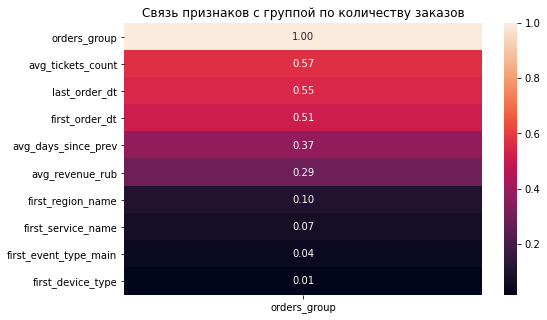

In [81]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    corr[['orders_group']].sort_values('orders_group', ascending=False),
    annot=True,
    fmt='.2f'
)

plt.title('Связь признаков с группой по количеству заказов')
plt.show()

Наиболее сильная связь с количеством заказов наблюдается у avg_tickets_count (0.57), last_order_dt (0.55) и first_order_dt (0.51). Умеренная связь есть у avg_days_since_prev (0.37) и avg_revenue_rub (0.29), тогда как остальные признаки имеют слабую связь.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

Общий вывод и рекомендации

В ходе исследования были проанализированы данные о заказах пользователей Яндекс Афиши. На этапе предобработки выручка в тенге была переведена в рубли, проверены пропуски и аномальные значения, после чего выбросы по выручке были отфильтрованы по 99-му перцентилю. На основе очищенных данных был сформирован профиль пользователей с информацией о количестве заказов, средней выручке, количестве билетов и интервалах между покупками.

Анализ показал, что вероятность повторной покупки связана прежде всего с характеристиками самого поведения пользователя. Пользователи с более высокой средней выручкой чаще возвращаются: у пользователей с одним заказом преобладает диапазон до 300 рублей, тогда как у вернувшихся пользователей — примерно 300–700 рублей. Наиболее высокая доля повторных покупок наблюдается у пользователей со средним количеством 2–3 билетов в заказе — 70,9%.

Признаки первого заказа оказывают значительно меньшее влияние. Пользователи, впервые покупавшие билеты на выставки и театр, возвращаются несколько чаще, а пользователи desktop — немного чаще пользователей mobile, однако различия между основными сегментами невелики. День недели первой покупки также практически не влияет на вероятность возврата.

Наиболее заметная временная закономерность связана с интервалом между покупками: у пользователей с 5 и более заказами средний интервал составляет 6,41 дня, тогда как у пользователей с 2–4 заказами — 17,52 дня. Корреляционный анализ также показал наиболее выраженную связь количества заказов со средним количеством билетов, датами первого и последнего заказа и интервалом между покупками.

Рекомендация: в первую очередь стоит сосредоточить маркетинговые усилия на пользователях, которые уже совершили покупку и приобретают около 2–3 билетов за заказ, стимулируя их к следующей покупке в течение короткого периода. При этом не стоит делать выводы о небольших сегментах без учёта их размера, поскольку их показатели могут быть нестабильными.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**